In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spark4ai-prediction/soil_dataset/sample_submission.csv
/kaggle/input/spark4ai-prediction/soil_dataset/train.csv
/kaggle/input/spark4ai-prediction/soil_dataset/test.csv


In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
import xgboost as xgb

In [3]:
train_df=pd.read_csv("/kaggle/input/spark4ai-prediction/soil_dataset/train.csv")
train_df.head()

,Id,Property_A,Property_B,Property_C,Property_D,Property_E,Property_F,A,B,C,...,2491 nm,2492 nm,2493 nm,2494 nm,2495 nm,2496 nm,2497 nm,2498 nm,2499 nm,2500 nm
0,1,5.99,0.115797,1.638,49.0,19.0,32.0,101745.9975,292211.0199,38816.97313,...,0.385093,0.384933,0.384977,0.385273,0.385507,0.384700,0.383193,0.382067,0.381257,0.381013
1,2,5.15,0.183483,1.482,47.0,16.0,37.0,105712.6402,315908.0751,39888.72776,...,0.404990,0.405053,0.405617,0.406607,0.407490,0.406543,0.404393,0.403207,0.402917,0.402393
2,3,5.55,0.173130,1.404,50.0,20.0,30.0,102621.3309,304334.3675,42120.98104,...,0.397750,0.397417,0.397273,0.397140,0.397013,0.396677,0.396240,0.396140,0.396370,0.397213
3,4,5.09,0.196011,1.638,50.0,15.0,35.0,113446.2881,311356.2657,39195.84181,...,0.382153,0.382130,0.382580,0.383233,0.383877,0.383550,0.382607,0.382263,0.382473,0.382533
4,5,4.73,0.203319,1.677,53.0,19.0,28.0,109714.6033,322110.4501,38347.65382,...,0.416157,0.416683,0.417567,0.417703,0.417420,0.416463,0.415003,0.414080,0.413637,0.413687


In [4]:
train_df.drop(columns=['Id'],inplace=True)
X=train_df.iloc[:,6:]
X.head()

,A,B,C,D,E,F,G,H,I,J,...,2491 nm,2492 nm,2493 nm,2494 nm,2495 nm,2496 nm,2497 nm,2498 nm,2499 nm,2500 nm
0,101745.9975,292211.0199,38816.97313,5308.374022,161.262201,107.877266,384.928482,52565.24979,50.560870,50.918543,...,0.385093,0.384933,0.384977,0.385273,0.385507,0.384700,0.383193,0.382067,0.381257,0.381013
1,105712.6402,315908.0751,39888.72776,5431.548180,150.652845,117.086301,372.064549,50665.24752,53.176087,49.900172,...,0.404990,0.405053,0.405617,0.406607,0.407490,0.406543,0.404393,0.403207,0.402917,0.402393
2,102621.3309,304334.3675,42120.98104,5513.664286,161.262201,97.352655,422.530751,52748.36917,52.304348,50.918543,...,0.397750,0.397417,0.397273,0.397140,0.397013,0.396677,0.396240,0.396140,0.396370,0.397213
3,113446.2881,311356.2657,39195.84181,5428.306755,169.749685,99.983808,396.802883,53893.69764,52.304348,49.900172,...,0.382153,0.382130,0.382580,0.383233,0.383877,0.383550,0.382607,0.382263,0.382473,0.382533
4,109714.6033,322110.4501,38347.65382,5431.548180,152.774716,130.242065,346.336681,48784.11209,49.689130,44.808317,...,0.416157,0.416683,0.417567,0.417703,0.417420,0.416463,0.415003,0.414080,0.413637,0.413687


In [5]:
y=train_df.iloc[:,:6]
y.head()

,Property_A,Property_B,Property_C,Property_D,Property_E,Property_F
0,5.99,0.115797,1.638,49.0,19.0,32.0
1,5.15,0.183483,1.482,47.0,16.0,37.0
2,5.55,0.173130,1.404,50.0,20.0,30.0
3,5.09,0.196011,1.638,50.0,15.0,35.0
4,4.73,0.203319,1.677,53.0,19.0,28.0


In [6]:
y['Pred'] = y.iloc[:,:6].sum(axis=1)
y = y.drop(y.columns[:6], axis=1)
y.head()

,Pred
0,107.743797
1,106.815483
2,107.127130
3,106.924011
4,106.610319


In [7]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
df_X = pd.DataFrame(X_scaled, columns=X.columns)

In [8]:
df_X.head()

,A,B,C,D,E,F,G,H,I,J,...,2491 nm,2492 nm,2493 nm,2494 nm,2495 nm,2496 nm,2497 nm,2498 nm,2499 nm,2500 nm
0,-0.423028,-0.912728,-0.701307,0.462106,0.075718,-0.053176,-0.434834,0.568089,-0.063179,0.515508,...,0.093582,0.088106,0.080470,0.085492,0.092310,0.082935,0.062346,0.039627,0.013704,0.000424
1,0.096357,0.282203,-0.250574,1.284049,-0.740206,0.668199,-0.529382,0.139141,0.345308,0.341585,...,0.624724,0.623969,0.628661,0.651241,0.674914,0.662481,0.626132,0.602528,0.590604,0.571260
2,-0.308413,-0.301405,0.688216,1.832012,0.075718,-0.877604,-0.158463,0.609430,0.209146,0.515508,...,0.431452,0.420579,0.407065,0.400190,0.397261,0.400699,0.409305,0.414362,0.416238,0.432956
3,1.108985,0.052677,-0.541972,1.262419,0.728456,-0.671497,-0.347559,0.868002,0.209146,0.341585,...,0.015099,0.013444,0.016816,0.031392,0.049112,0.052424,0.046744,0.044864,0.046109,0.041007
4,0.620366,0.594959,-0.898683,1.284049,-0.577021,1.698734,-0.718478,-0.285548,-0.199342,-0.528030,...,0.922818,0.933714,0.946049,0.945520,0.938080,0.925678,0.908291,0.892055,0.876125,0.872787


In [9]:
A=df_X.iloc[:,:16]
A.head()

,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P
0,-0.423028,-0.912728,-0.701307,0.462106,0.075718,-0.053176,-0.434834,0.568089,-0.063179,0.515508,-0.096193,-0.023980,-0.245899,-0.698381,0.170332,-0.629133
1,0.096357,0.282203,-0.250574,1.284049,-0.740206,0.668199,-0.529382,0.139141,0.345308,0.341585,-0.451586,-0.023980,-0.349567,-0.486365,0.796555,-0.219541
2,-0.308413,-0.301405,0.688216,1.832012,0.075718,-0.877604,-0.158463,0.609430,0.209146,0.515508,0.377664,-0.023980,0.790776,-0.380357,2.048999,0.599642
3,1.108985,0.052677,-0.541972,1.262419,0.728456,-0.671497,-0.347559,0.868002,0.209146,0.341585,0.022271,0.575521,0.583441,-0.804389,0.796555,0.190051
4,0.620366,0.594959,-0.898683,1.284049,-0.577021,1.698734,-0.718478,-0.285548,-0.199342,-0.528030,0.259200,-0.623481,-0.349567,-0.486365,0.170332,-1.038725


In [10]:
B=df_X.iloc[:,16:]
B.head()

,350 nm,351 nm,352 nm,353 nm,354 nm,355 nm,356 nm,357 nm,358 nm,359 nm,...,2491 nm,2492 nm,2493 nm,2494 nm,2495 nm,2496 nm,2497 nm,2498 nm,2499 nm,2500 nm
0,0.068680,-0.006410,-0.042317,0.036869,-0.007229,-0.148739,-0.070489,-0.010895,-0.033990,-0.081293,...,0.093582,0.088106,0.080470,0.085492,0.092310,0.082935,0.062346,0.039627,0.013704,0.000424
1,0.228464,0.189024,0.183442,0.228727,0.229382,0.186874,0.201537,0.157489,0.033084,0.051419,...,0.624724,0.623969,0.628661,0.651241,0.674914,0.662481,0.626132,0.602528,0.590604,0.571260
2,0.189359,0.250162,0.276508,0.183102,0.158594,0.206654,0.183481,0.173844,0.196220,0.168953,...,0.431452,0.420579,0.407065,0.400190,0.397261,0.400699,0.409305,0.414362,0.416238,0.432956
3,-0.016651,0.025128,0.054750,-0.080638,-0.112563,-0.031099,-0.002057,-0.005793,-0.041789,-0.070266,...,0.015099,0.013444,0.016816,0.031392,0.049112,0.052424,0.046744,0.044864,0.046109,0.041007
4,0.323376,0.310783,0.275991,0.144106,0.140474,0.259618,0.297446,0.267521,0.174122,0.183223,...,0.922818,0.933714,0.946049,0.945520,0.938080,0.925678,0.908291,0.892055,0.876125,0.872787


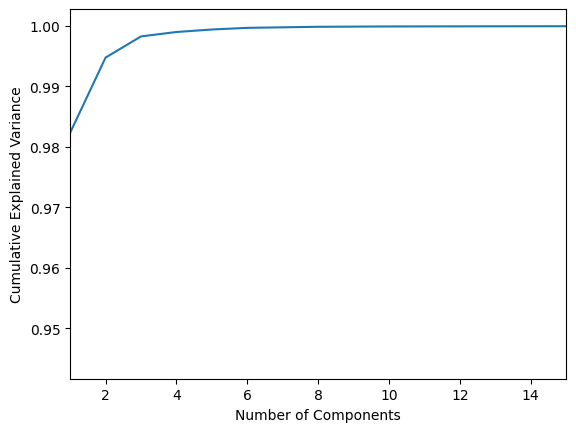

In [11]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(B)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
import matplotlib.pyplot as plt

plt.plot(cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.xlim(1,15)
plt.show()


In [12]:
pca = PCA(n_components=50)
reduced_B = pca.fit_transform(B)
scaler = StandardScaler()

# Scale the reduced_B data
scaled_reduced_B = scaler.fit_transform(reduced_B)

In [13]:
reduced_B_df = pd.DataFrame(scaled_reduced_B, columns=[f'PC{i}' for i in range(1, 51)])

In [14]:
reduced_B_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
0,-0.392448,-0.105674,-1.183193,0.386715,-1.215803,0.918118,2.623520,0.674270,0.162253,1.219035,...,-0.672089,0.663549,0.959887,0.059903,-0.496760,0.723873,-0.779455,-1.937013,-0.768679,-0.811065
1,-0.844336,-0.780158,-1.103225,0.441172,-1.010735,-0.378233,1.610029,-1.488625,3.010977,0.127130,...,1.209980,1.032004,-0.257165,0.286085,0.613550,-1.028700,-1.284644,0.807233,-1.657900,-0.556856
2,-0.428419,-0.422440,0.149675,-0.127114,-0.616434,0.544656,1.214654,0.201038,-1.073092,-1.473443,...,-2.404970,-0.378757,-0.128485,0.246182,0.368672,0.463499,-1.587996,1.355493,1.595469,-2.124818
3,-0.231269,-0.623717,-0.998833,-0.413450,0.047079,-0.030167,0.285918,1.374739,-0.604801,-0.963207,...,-2.128522,-0.659499,1.618240,1.590019,0.391715,-0.378088,-0.281837,2.347368,1.973469,0.453360
4,-0.994372,-1.361601,-0.525247,-0.836098,-0.043373,2.147146,0.069799,0.654796,-0.635559,-0.942227,...,-2.200286,1.032200,-0.580557,0.284694,-0.069342,-0.561746,-0.737017,1.602774,-0.928336,-2.389134


In [15]:
concatenated_df = pd.concat([A, reduced_B_df], axis=1)

In [16]:
concatenated_df.head()

,A,B,C,D,E,F,G,H,I,J,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
0,-0.423028,-0.912728,-0.701307,0.462106,0.075718,-0.053176,-0.434834,0.568089,-0.063179,0.515508,...,-0.672089,0.663549,0.959887,0.059903,-0.496760,0.723873,-0.779455,-1.937013,-0.768679,-0.811065
1,0.096357,0.282203,-0.250574,1.284049,-0.740206,0.668199,-0.529382,0.139141,0.345308,0.341585,...,1.209980,1.032004,-0.257165,0.286085,0.613550,-1.028700,-1.284644,0.807233,-1.657900,-0.556856
2,-0.308413,-0.301405,0.688216,1.832012,0.075718,-0.877604,-0.158463,0.609430,0.209146,0.515508,...,-2.404970,-0.378757,-0.128485,0.246182,0.368672,0.463499,-1.587996,1.355493,1.595469,-2.124818
3,1.108985,0.052677,-0.541972,1.262419,0.728456,-0.671497,-0.347559,0.868002,0.209146,0.341585,...,-2.128522,-0.659499,1.618240,1.590019,0.391715,-0.378088,-0.281837,2.347368,1.973469,0.453360
4,0.620366,0.594959,-0.898683,1.284049,-0.577021,1.698734,-0.718478,-0.285548,-0.199342,-0.528030,...,-2.200286,1.032200,-0.580557,0.284694,-0.069342,-0.561746,-0.737017,1.602774,-0.928336,-2.389134


In [17]:
X_train, X_test, y_train, y_test = train_test_split(concatenated_df, y, test_size=0.3, random_state=42)

# Step 2: Initialize the Linear Regression model
model = LinearRegression()

# Step 3: Fit the model on the training data
model.fit(X_train, y_train)

# Step 4: Predict the target variable on the test set
y_pred = model.predict(X_test)

In [18]:
y_pred[0]

array([108.76311483])

In [19]:
mse=mean_squared_error(y_pred,y_test,squared=False)

In [20]:
mse

0.5812863811252716

In [21]:
num_folds = 10
cv_scores = cross_val_score(model, X_train, y_train, cv=num_folds, scoring='neg_mean_squared_error')

cv_scores = -cv_scores

rmse_scores = np.sqrt(cv_scores)


for i, score in enumerate(rmse_scores):
    print(f'Fold {i+1} RMSE: {score}')

average_rmse = np.mean(rmse_scores)
print(f'Average RMSE: {average_rmse}')

Fold 1 RMSE: 0.961360449089574
Fold 2 RMSE: 0.5586249440060369
Fold 3 RMSE: 0.7270781950982381
Fold 4 RMSE: 0.8170549302716211
Fold 5 RMSE: 1.001202506505412
Fold 6 RMSE: 0.7856378080622416
Fold 7 RMSE: 0.765824249601501
Fold 8 RMSE: 0.9930773272528471
Fold 9 RMSE: 0.5515471404819702
Fold 10 RMSE: 0.6115611164905167
Average RMSE: 0.7772968666859958
